In [6]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from collections import Counter
i = [1,2,2,3,3,3,4,4,4,4]
freq = Counter(i)
top3=freq.most_common(2)
for num, count in top3:
    print(f"Number: {num}, Count: {count}")




Number: 4, Count: 4
Number: 3, Count: 3


In [ ]:
data = {
"Aman": [85, 90, 78],
"Eakam": [92, 88, 95],
"Kiran": [70, 75, 80]
}

averages = {}# dictionary to store average marks of each student

# calculate average of each student
for student, marks in data.items():
    avg = sum(marks) / len(marks)
    averages[student] = avg
    print(student + ":", round(avg,1))#avg,1 is used to round the average to 1 decimal place

# find student with highest average
top_student = max(averages, key=averages.get)

print("Top Student:", top_student)

Aman: 84.3
Eakam: 91.7
Kiran: 75.0
Top Student: Eakam


In [9]:
df=pd.read_csv("Dataset_Pr_2_ML (1).csv")

In [10]:
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [11]:
df.shape

(14999, 10)

In [12]:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [13]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='str')

In [14]:
df.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                   str
salary                       str
dtype: object

In [15]:
df.fillna(df.mean(numeric_only=True),inplace=True)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [16]:
for col in df.select_dtypes(include="object"):
    df[col].fillna(df[col].mode()[0],inplace=True)

C:\Users\sharm\AppData\Local\Temp\ipykernel_8880\1688931175.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object"):
C:\Users\sharm\AppData\Local\Temp\ipykernel_8880\1688931175.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].

In [17]:
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [18]:
df=df.drop_duplicates()

In [19]:
df.drop("Work_accident", axis=1, inplace=True)


In [20]:
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,1,0,sales,low
1,0.80,0.86,5,262,6,1,0,sales,medium
2,0.11,0.88,7,272,4,1,0,sales,medium
3,0.72,0.87,5,223,5,1,0,sales,low
4,0.37,0.52,2,159,3,1,0,sales,low
...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,0,1,management,high
11996,0.74,0.95,5,266,10,0,1,management,high
11997,0.85,0.54,3,185,10,0,1,management,high
11998,0.33,0.65,3,172,10,0,1,marketing,high


In [21]:
df.drop("left", axis=1, inplace=True)

In [22]:
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,sales,low
1,0.80,0.86,5,262,6,0,sales,medium
2,0.11,0.88,7,272,4,0,sales,medium
3,0.72,0.87,5,223,5,0,sales,low
4,0.37,0.52,2,159,3,0,sales,low
...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,management,high
11996,0.74,0.95,5,266,10,1,management,high
11997,0.85,0.54,3,185,10,1,management,high
11998,0.33,0.65,3,172,10,1,marketing,high


In [23]:
df.dropna(inplace=True)

In [24]:
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,sales,low
1,0.80,0.86,5,262,6,0,sales,medium
2,0.11,0.88,7,272,4,0,sales,medium
3,0.72,0.87,5,223,5,0,sales,low
4,0.37,0.52,2,159,3,0,sales,low
...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,management,high
11996,0.74,0.95,5,266,10,1,management,high
11997,0.85,0.54,3,185,10,1,management,high
11998,0.33,0.65,3,172,10,1,marketing,high


In [25]:
df.info()

<class 'pandas.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_montly_hours   11991 non-null  int64  
 4   time_spend_company     11991 non-null  int64  
 5   promotion_last_5years  11991 non-null  int64  
 6   Department             11991 non-null  str    
 7   salary                 11991 non-null  str    
dtypes: float64(2), int64(4), str(2)
memory usage: 843.1 KB


In [26]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [27]:
df['Department'] = le.fit_transform(df['Department'])
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,7,low
1,0.80,0.86,5,262,6,0,7,medium
2,0.11,0.88,7,272,4,0,7,medium
3,0.72,0.87,5,223,5,0,7,low
4,0.37,0.52,2,159,3,0,7,low
...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,4,high
11996,0.74,0.95,5,266,10,1,4,high
11997,0.85,0.54,3,185,10,1,4,high
11998,0.33,0.65,3,172,10,1,5,high


In [28]:
df['salary'] = le.fit_transform(df['salary'])
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,7,1
1,0.80,0.86,5,262,6,0,7,2
2,0.11,0.88,7,272,4,0,7,2
3,0.72,0.87,5,223,5,0,7,1
4,0.37,0.52,2,159,3,0,7,1
...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,4,0
11996,0.74,0.95,5,266,10,1,4,0
11997,0.85,0.54,3,185,10,1,4,0
11998,0.33,0.65,3,172,10,1,5,0


In [29]:
dff=pd.read_csv("Dataset_Pr_2_ML (1).csv")

In [30]:
fig=px.histogram(dff, x="Department", color="Department", title="Distribution of Employees by Department")
fig.show()

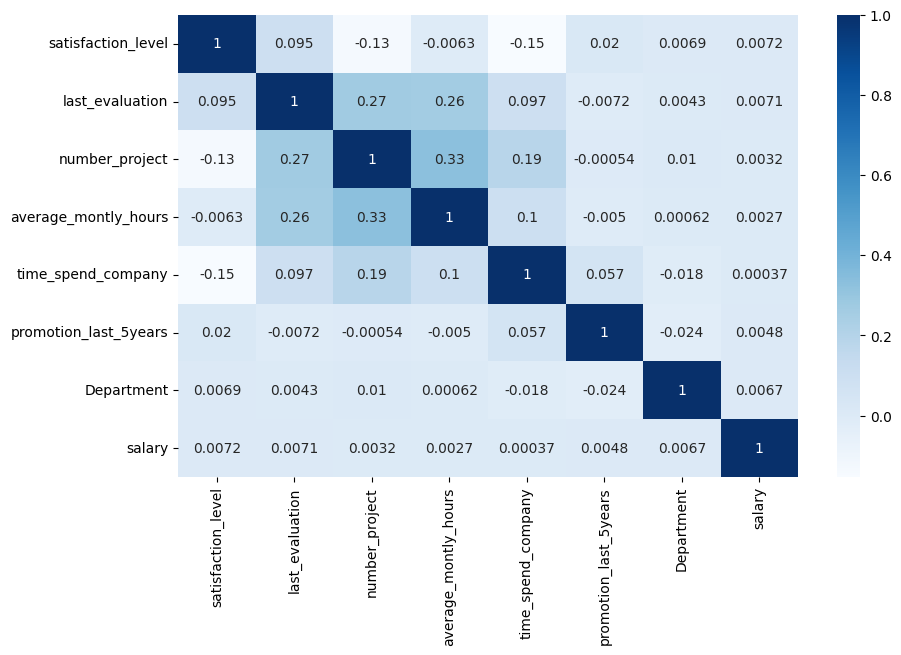

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='Blues')
plt.show()

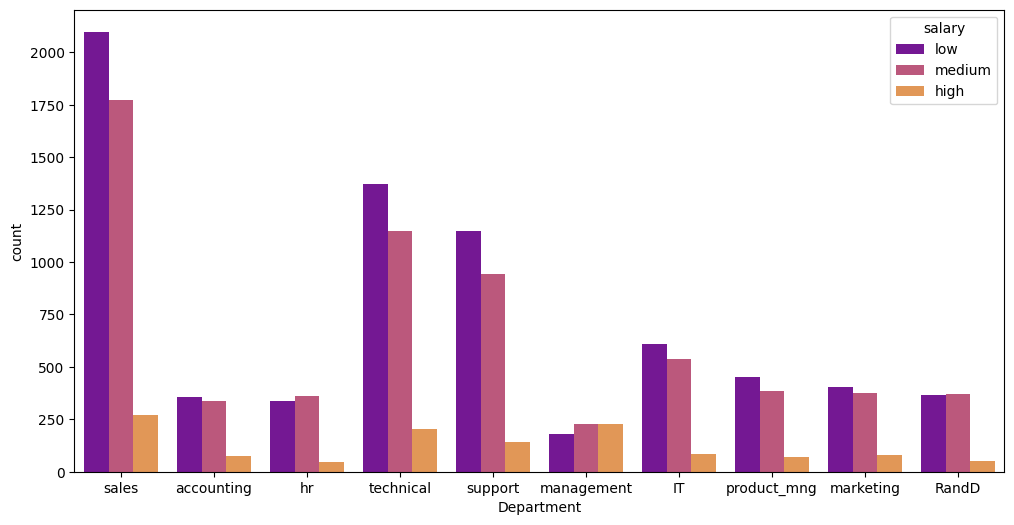

In [32]:
plt.figure(figsize=(12,6))
sns.countplot(data=dff,x='Department',hue='salary',palette='plasma')
plt.show()

In [33]:
fig=px.box(data_frame=df,x="average_montly_hours")
fig.show()

In [34]:
px.scatter(dff, x="satisfaction_level", y="last_evaluation", color="Department")

In [35]:
px.scatter(dff, x="average_montly_hours", y="salary",color='Department' )

In [36]:
####### IQR method to find outliers #######


Q1 = df["average_montly_hours"].quantile(0.25)
Q3 = df["average_montly_hours"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["average_montly_hours"] < (Q1 - 1.5 * IQR)) | 
              (df["average_montly_hours"] > (Q3 + 1.5 * IQR))]

print(outliers)

Empty DataFrame
Columns: [satisfaction_level, last_evaluation, number_project, average_montly_hours, time_spend_company, promotion_last_5years, Department, salary]
Index: []


In [37]:
df=df.drop("Department",axis=1)

In [38]:
df["workload_per_year"] = df["average_montly_hours"] * 12
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,promotion_last_5years,salary,workload_per_year
0,0.38,0.53,2,157,3,0,1,1884
1,0.80,0.86,5,262,6,0,2,3144
2,0.11,0.88,7,272,4,0,2,3264
3,0.72,0.87,5,223,5,0,1,2676
4,0.37,0.52,2,159,3,0,1,1908
...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,0,3108
11996,0.74,0.95,5,266,10,1,0,3192
11997,0.85,0.54,3,185,10,1,0,2220
11998,0.33,0.65,3,172,10,1,0,2064


In [39]:
y=df.salary
x=df.drop('salary',axis=1)

In [40]:
x

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,promotion_last_5years,workload_per_year
0,0.38,0.53,2,157,3,0,1884
1,0.80,0.86,5,262,6,0,3144
2,0.11,0.88,7,272,4,0,3264
3,0.72,0.87,5,223,5,0,2676
4,0.37,0.52,2,159,3,0,1908
...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,3108
11996,0.74,0.95,5,266,10,1,3192
11997,0.85,0.54,3,185,10,1,2220
11998,0.33,0.65,3,172,10,1,2064


In [41]:
y

0        1
1        2
2        2
3        1
4        1
        ..
11995    0
11996    0
11997    0
11998    0
11999    1
Name: salary, Length: 11991, dtype: int64

In [42]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [43]:
x_train

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,promotion_last_5years,workload_per_year
9413,0.67,0.63,3,270,5,0,3240
3512,0.52,0.92,3,214,3,0,2568
2028,0.61,0.98,3,267,3,0,3204
887,0.41,0.51,2,137,3,0,1644
3774,0.55,0.74,3,211,3,0,2532
...,...,...,...,...,...,...,...
2315,0.78,0.76,5,168,4,0,2016
6607,0.68,0.89,4,227,3,0,2724
5382,0.19,0.72,6,243,6,0,2916
6287,0.82,0.62,4,267,3,0,3204


In [44]:
y_train

9413     1
3512     1
2028     1
887      2
3774     0
        ..
2315     1
6607     2
5382     1
6287     2
11320    2
Name: salary, Length: 9592, dtype: int64